In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

labels = pd.read_csv('labels.csv', dtype={'track_id': str})


labels

,track_id,track_genre
0,000002,Hip-Hop
1,000003,Hip-Hop
2,000005,Hip-Hop
3,000010,Pop
4,000134,Hip-Hop
...,...,...
48667,155315,Rock
48668,155316,Rock
48669,155317,Rock
48670,155318,Rock


### Interesują nas tylko tracki obecne zarówno w fma_small jak i w labels

In [12]:
import os
print("cwd:", os.getcwd())
FMA_ROOT = Path("..") / "fma_tracks" / "fma_small"
print("FMA_ROOT exists:", FMA_ROOT.exists())


cwd: /Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/PROJEKT
FMA_ROOT exists: True


### Mamy 8000 tracków w fma_small, az 50000 w labels -> inner join

In [17]:
mp3s = list(FMA_ROOT.rglob("*.mp3"))

# mp3 ids (strings)
ids = {p.stem for p in FMA_ROOT.rglob("*.mp3") if p.stem.isdigit() and len(p.stem) == 6}

# labels ids (strings)
label_ids = set(labels["track_id"].astype(str))

# ONE intersection
good_ids = ids & label_ids

# filter labels
labels = labels[labels["track_id"].astype(str).isin(good_ids)].copy()

len(good_ids), labels.shape




(8000, (8000, 2))

In [19]:
labels.to_csv('labels.csv', index = False)

## 1. Class Imbalance

<Axes: xlabel='count', ylabel='track_genre'>

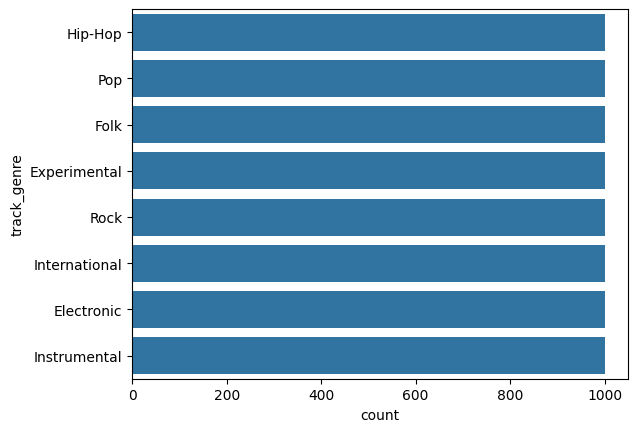

In [20]:
sns.countplot(data = labels, y = 'track_genre')

## 2. Sound statistics

In [27]:
import numpy as np

def spectrogram_stats(X: np.ndarray) -> dict:
    x = X.astype(np.float32).ravel()
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "median": float(np.median(x)),
        "q25": float(np.quantile(x, 0.25)),
        "q75": float(np.quantile(x, 0.75)),
        "q90": float(np.quantile(x, 0.90)),
        "energy_mean_sq": float(np.mean(x * x)),          # average energy
        "sparsity_frac0": float(np.mean(x <= 1e-6)),      # fraction ~0
    }


### Tworze spektrogramy

In [30]:
import os
import numpy as np
import librosa
from pydub import AudioSegment

def cut_and_save_logmel_ffmpeg(
    input_path: str,
    output_folder: str,
    track_id: str,
    genre: str | None,
    stats_rows: list,                 # <-- pass a list here to collect rows
    seconds: float = 3.0,
    sr: int = 22050,
    n_mels: int = 128,
    n_fft: int = 2048,
    hop_length: int = 512,
    fmin: float = 20.0,
    fmax: float | None = 8000.0,
    top_db: float = 80.0,
    time_bins: int = 128,
    seed: int | None = None,
):
    try:
        audio = AudioSegment.from_file(input_path, format="mp3")
        audio = audio.set_channels(1).set_frame_rate(sr)

        samples = np.array(audio.get_array_of_samples())
        max_val = float(2 ** (8 * audio.sample_width - 1))
        y = samples.astype(np.float32) / max_val

        desired_len = int(round(seconds * sr))
        if len(y) < desired_len:
            return None

        rng = np.random.default_rng(seed)
        start = int(rng.integers(0, len(y) - desired_len + 1))
        y = y[start : start + desired_len]

        fmax_eff = (sr / 2) if fmax is None else min(float(fmax), sr / 2)

        S = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=n_fft,
            window="hann",
            center=False,
            power=2.0,
            n_mels=n_mels,
            fmin=fmin,
            fmax=fmax_eff,
            htk=False,
            norm="slaney",
        )

        S_db = librosa.power_to_db(S, ref=1.0, top_db=top_db)
        X = (S_db + top_db) / top_db
        X = np.clip(X, 0.0, 1.0)

        # force fixed time dim
        T = X.shape[1]
        if T < time_bins:
            X = np.pad(X, ((0, 0), (0, time_bins - T)), mode="constant", constant_values=0.0)
        else:
            X = X[:, :time_bins]

        if X.shape != (n_mels, time_bins):
            return None
        if not np.isfinite(X).all():
            return None
        if np.max(X) <= 0.0:
            return None

        os.makedirs(output_folder, exist_ok=True)
        out_path = os.path.join(output_folder, f"{track_id}.npy")
        np.save(out_path, X.astype(np.float32))

        # --- NEW: compute + store stats row ---
        row = {"track_id": str(track_id), "genre": genre}
        row.update(spectrogram_stats(X))
        stats_rows.append(row)

        return out_path

    except Exception:
        return None


In [31]:
SEED = 123
TARGET_N = 10_000
stats_rows = []
base_dir = "../fma_tracks/fma_small"
spec_dir = "spectrograms"
output_csv = "good_labels.csv"

os.makedirs(spec_dir, exist_ok=True)
random.seed(SEED)

# --- labels ids as 6-digit strings
labels2 = labels.copy()
labels2["track_id"] = labels2["track_id"].astype(str).str.zfill(6)

# --- collect all mp3 paths and ids (filename stem)
mp3_paths = [
    os.path.join(root, f)
    for root, _, files in os.walk(base_dir)
    for f in files
    if f.lower().endswith(".mp3")
]

mp3_id_to_path = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in mp3_paths
}

mp3_ids = set(mp3_id_to_path.keys())
label_ids = set(labels2["track_id"])

# --- ONE intersection
good_pool = sorted(mp3_ids & label_ids)

# --- sample ids
k = min(TARGET_N, len(good_pool))
sample_ids = random.sample(good_pool, k=k)

id_to_genre = dict(zip(labels2["track_id"], labels2["track_genre"]))

good_ids, bad_ids = [], []

for i, tid in enumerate(sample_ids, 1):
    path = mp3_id_to_path[tid]

    out = cut_and_save_logmel_ffmpeg(
        input_path=path,
        output_folder=spec_dir,
        track_id=tid,
        genre=id_to_genre.get(tid),     # <-- added
        seconds=3.0,
        seed=SEED + int(tid),
        stats_rows=stats_rows
    )

    if out is None:
        bad_ids.append(tid)
    else:
        good_ids.append(tid)

    if i % 200 == 0:
        print(f"Processed {i}/{k}")

# --- save labels for successful spectrograms
used_labels = labels2[labels2["track_id"].isin(good_ids)].copy()
used_labels.to_csv(output_csv, index=False)

pd.DataFrame({"track_id": bad_ids}).to_csv("bad_ids.csv", index=False)

print("Done.")
print("mp3 files:", len(mp3_paths))
print("intersection pool:", len(good_pool))
print("sampled:", len(sample_ids))
print("good:", len(good_ids))
print("bad:", len(bad_ids))
print("labels rows saved:", len(used_labels))


Processed 200/8000
Processed 400/8000
Processed 600/8000
Processed 800/8000
Processed 1000/8000
Processed 1200/8000
Processed 1400/8000
Processed 1600/8000
Processed 1800/8000
Processed 2000/8000
Processed 2200/8000
Processed 2400/8000
Processed 2600/8000
Processed 2800/8000
Processed 3000/8000
Processed 3200/8000
Processed 3400/8000
Processed 3600/8000
Processed 3800/8000
Processed 4000/8000
Processed 4200/8000
Processed 4400/8000
Processed 4600/8000
Processed 4800/8000
Processed 5000/8000
Processed 5200/8000
Processed 5400/8000
Processed 5600/8000
Processed 5800/8000
Processed 6000/8000
Processed 6200/8000
Processed 6400/8000
Processed 6600/8000
Processed 6800/8000
Processed 7000/8000
Processed 7200/8000
Processed 7400/8000
Processed 7600/8000
Processed 7800/8000
Processed 8000/8000
Done.
mp3 files: 8000
intersection pool: 8000
sampled: 8000
good: 7991
bad: 9
labels rows saved: 7991


### Spectrogram - based stats

In [32]:
pd.DataFrame(stats_rows).to_csv("spectrogram_stats.csv", index=False)

In [33]:
spec_stats = pd.read_csv('spectrogram_stats.csv', dtype = {'track_id': str})

spec_stats

,track_id,genre,mean,std,min,max,median,q25,q75,q90,energy_mean_sq,sparsity_frac0
0,010440,Folk,0.810722,0.198902,0.0,1.0,0.869870,0.678689,0.989685,1.000000,0.696833,0.015625
1,053576,Folk,0.712833,0.185727,0.0,1.0,0.720755,0.617417,0.831258,0.966137,0.542626,0.015625
2,014653,Rock,0.908964,0.143020,0.0,1.0,0.948262,0.861947,1.000000,1.000000,0.846671,0.015625
3,126182,Instrumental,0.950261,0.129829,0.0,1.0,0.996847,0.937805,1.000000,1.000000,0.919851,0.015625
4,073761,International,0.886362,0.145618,0.0,1.0,0.909867,0.826313,1.000000,1.000000,0.806843,0.015625
...,...,...,...,...,...,...,...,...,...,...,...,...
7986,076079,International,0.843794,0.167114,0.0,1.0,0.869599,0.762808,0.994506,1.000000,0.739915,0.015625
7987,060478,Hip-Hop,0.938513,0.132064,0.0,1.0,0.977911,0.918121,1.000000,1.000000,0.898248,0.015625
7988,042375,Electronic,0.817333,0.177927,0.0,1.0,0.844315,0.720237,0.971361,1.000000,0.699692,0.015625
7989,145462,Electronic,0.820499,0.131630,0.0,1.0,0.835630,0.779608,0.888905,0.936070,0.690546,0.015625
